In [94]:
def thomas_algorithm(a, b, c, d):# From Slides 
    """
    Solve the tridiagonal system using the Thomas algorithm.

    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)

    Returns: solution vector x of length n
    """

    n = len(b)

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x



def solveSpline(x, y, xValue):

    h = [] ##empty array 
    for i in range(len(x) - 1): ##number of calculations (h2-h1 type) within array
        h.append(x[i+1] - x[i]) 

    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(len(x) - 2)  # Subdiagonal
    B = np.zeros(len(x) - 2)  # Main diagonal
    C = np.zeros(len(x) - 2)  # Superdiagonal
    D = np.zeros(len(x) - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    count = 0
    for i in range(1, len(x) - 1):
       # count = x[i] 
        #if (i = 1):
        #    A[i - 1] = 0 
        #elif (i > 1):
        ##    for ()
        A[i - 1] =  h[i-1]       # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])        # Main diagonal
        C[i - 1] = h[i]        # Superdiagonal 
        D[i - 1] = 6 * ( (y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1]  )       # Right-hand side vector


    
    mInterior =  thomas_algorithm(A, B, C, D)
    
    m = np.zeros(len(x))
    for i in range (1, len(x) - 1) :
        m[i] = mInterior[i-1] ##finding inner m values, 


    for i in range (len(x) - 1):
        if (x[i] <= xValue and xValue <= x[i+1]): ##finding which "i" the xValue from input pertains, find the value from the spline using interpolation
        ##solving for the splice 
            S = (
            ( m[i] / (6 * h[i] )) * (x[i+1]  - xValue)**3 +
            ( m[i+1] / ( 6 * h[i]) ) * (xValue - x[i] )**3 +
            ( y[i] / h[i] - m[i] * h[i] / 6) * (x[i+1] - xValue ) +
            ( y[i+1] / h[i] - m[i+1] * h[i] /6 ) * (xValue - x[i] )
            ) ##formula from slide s
            
            return S

    
##Part B 

def vandermond (vector, degree): ##Returns what np.vander() does, self-explanatory, returns an array of "vector" length, each mdae up of a subsequent increase in degree until it matches that of the input
    term = []
    output = []

    
    for i in range(len(vector)):
        j = degree 
        while (j > -1):
            term.append(vector[i]**j)
            j = j -1

        output.append(term)
        term = []
        
    return output
            
def leastSquare (vector1, vector2, degree): ## Pulled from homework 5 
    
    xtotal = 0 
    ytotal = 0
    xy = 0 
    xSquared = 0
    
    # Vandermond Matrix 
    ##np.vander
    
    a = vandermond(vector1, degree)
    a = np.array(a)

    
    
    # Solving System of Linear Equations, sourced from slides 
    
    # a.T * vector2(y)
    VT_V = np.dot(a.T, a)

    # a.T * y
    VT_y = np.dot(a.T, vector2)

    # Solve for a (coefficients)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients 
    
    
    
    


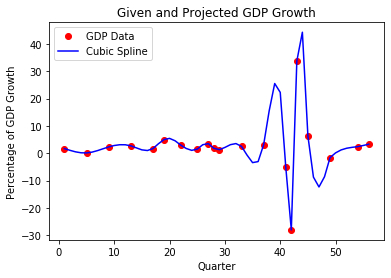

In [95]:
##Part A 
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

xCompleted = []
for i in range (1, 57):
    xCompleted.append(i)
plt.plot(x, y, 'ro', label="GDP Data")
plt.ylabel("Percentage of GDP Growth")
plt.xlabel("Quarter")
plt.title("Given and Projected GDP Growth")


splineValues = []
for i in range (1, 57):
    splineValues.append(solveSpline(x, y, i))
 

plt.plot(xCompleted, splineValues, 'b-', label="Cubic Spline")

plt.legend()
plt.show()


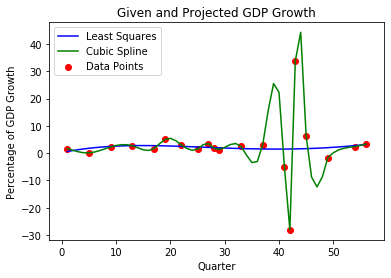

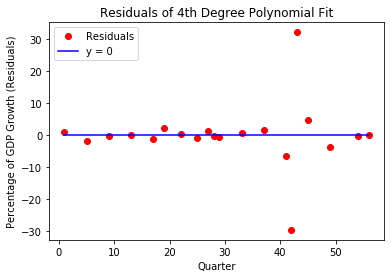

The RSME value is: 10.031440678677116


In [122]:
#Part B 

#Part 1 
import numpy as np
import matplotlib.pyplot as plt

##Repeat from Part A 
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


#Least Squares Graphing 
xCompleted = np.arange(1, 57)
     
slopeLeastSquared = leastSquare(x, y, 4) ##Instructions say degree four, order of input is x values as above, y values as above, and the 4th degree
predictY = (slopeLeastSquared[0]*(xCompleted**4) + slopeLeastSquared[1]*(xCompleted**3) + slopeLeastSquared[2]*(xCompleted**2) + slopeLeastSquared[3]*xCompleted + slopeLeastSquared[4]) ##Utilized CHATGPT to debug this specific line of code for a long time, it was going in ascending order instead of descending and this was causing issues

plt.plot(xCompleted, predictY, color="blue", label="Least Squares")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth")
plt.title("Given and Projected GDP Growth")
plt.scatter(x, y, color="red", label="Data Points")



#Cubic Spline Graphing 
xCompleted = []
for i in range (1, 57):
    xCompleted.append(i)
plt.ylabel("Percentage of GDP Growth")
plt.xlabel("Quarter")
plt.title("Given and Projected GDP Growth")


splineValues = []
for i in range (1, 57):
    splineValues.append(solveSpline(x, y, i))
 
plt.plot(xCompleted, splineValues,'g-', label="Cubic Spline")
plt.legend()
plt.show()


##Residual Plot 
#same as predictY on top but instead of doing it for all 56 values instead we are utilizing it for only the values that we have the actual data points are, to retrofit how far off the original equation is
predictY = (slopeLeastSquared[0]*(x**4) + slopeLeastSquared[1]*(x**3) + slopeLeastSquared[2]*(x**2) + slopeLeastSquared[3]*x + slopeLeastSquared[4]) ##Utilized CHATGPT to debug this specific line of code for a long time, it was going in ascending order instead of descending and this was causing issues

residual = y - predictY  
plt.plot(x, residual, 'ro', label="Residuals")
plt.plot(x, [0]*len(x), 'blue', label="y = 0")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth (Residuals)")
plt.title("Residuals of 4th Degree Polynomial Fit") 
plt.legend()
plt.show()

##The farther the residual points are from y = 0, the higher the deviancy is from the original plot. This means that espeecially during the covid years there is an extremely high deviance from the given data points, to the given actual values. 


# RSME calculation 
residualSum = 0
for i in range (len(residual)):
    residualSum = residualSum + residual[i] * residual[i]
RMSE = (residualSum / len(residual)) ** .5

print("The RSME value is: " + str(RMSE) )

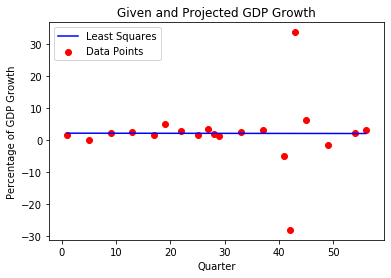

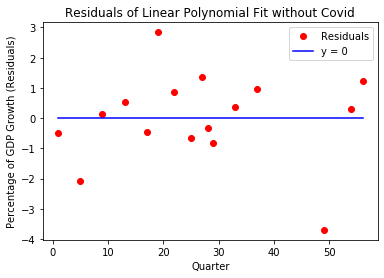

The RSME value is: 1.4431864883291987


In [124]:
#Part B
#Part 2 

import numpy as np
import matplotlib.pyplot as plt

##Repeat from Part A + Part B 
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

##Covidless quarters from array are when x do not equal 13, 14, 15, 16 
xCovidless = []
yCovidless = []
for i in range (0, len(x)):
    if (i != 13 and i!= 14 and i!= 15 and i!= 16):
        xCovidless.append(x[i])
        yCovidless.append(y[i])
     

#Least Squares Graphing 
xCompleted = np.arange(1, 57)
     
#Says it will be linear so that means that degree is 1 
slopeLeastSquared = leastSquare(xCovidless, yCovidless, 1) ##Instructions say degree four, order of input is x values as above, y values as above, and the 4th degree
predictY = slopeLeastSquared[1] + xCompleted*slopeLeastSquared[0]

plt.plot(xCompleted, predictY, color="blue", label="Least Squares")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth")
plt.title("Given and Projected GDP Growth")
plt.scatter(x, y, color="red", label="Data Points")
plt.legend()
plt.show()

##It makes sense to plot the graph linearly because the data points excluding covid have very little deviation. Thus, it makes perfect sense from an overall GDP standpoint. However, from a year to year standpoint looking at extremely short term economic growth, it is poor because it is difficutl to asceertain the month by month fluctuations. This graph however is great for macro, decades long points of data. It requries the assumption that this will be utilized in my opinoin on a muhc lengthier period of scale where small flucations do not matter as much

# Residuals 
predictY = np.array(slopeLeastSquared[0])*np.array(xCovidless) + np.array(slopeLeastSquared[1])
residual = np.array(yCovidless) - predictY  
plt.plot(xCovidless, residual, 'ro', label="Residuals")
plt.plot(xCovidless, [0]*len(xCovidless), 'blue', label="y = 0")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth (Residuals)")
plt.title("Residuals of Linear Polynomial Fit without Covid")
plt.legend()
plt.show()

          # RSME calculation - adapted from part B1 
residualSum = 0
for i in range (len(residual)):
    residualSum = residualSum + residual[i] * residual[i]
RMSE = (residualSum / len(residual)) ** .5

print("The RSME value is: " + str(RMSE) )



In [ ]:
#Part C 
''' The better choice is Cubic Spline because the graph for one is more fluid, making it more reasonable to read, furthermore the graph goes through each data point making it more accurate for the values interpolated in unknown x values. The accuracy of the cubic spline is at the very least is accurate to the given data points, while polynomial fitting only goes through a handful of points. 

Introduction: The dataset provided is a list of quarters in a fiscal year along with GDP growth within that quarter. The data orignates from the U.S. Bureau of Economic Analysis (BEA) and is given in the project PDF. In this project, I have utilized Cubic Spline and Least Squares methods to interpolate points on the graph. Furthermore, residuals and RMSE were calculated for the benefit of the Least Squared method. 




Part A:
The Cubic Spline is a means of interpolating where through a series of points, a third degree polynomial is created to account for the span between these two points. To solve the Cubic Spline a series of equations are solved in order to determine the value of each "m" at each point given as a value. We know that the first M, and the last M are 0, so a system of equations is utilized in order to find the coefficients of these interior Ms, the Thomas Equation solved the Ms. Using the Ms, the y values can be predicted at every X. The graph showed that the results were extremely accurate in predicting the y values of all quarters (x values). This was true with both covid taken into account, and covidless data. 

1. 


Part B: 
The second method that is utilized is Least Squares. A seperate Vandermond function was made. The least squares made was akin to a "line of best fit" of the values. A system of equations was again made here but instead solved by "np.linalg.solve", for the variabels a,b,c,d. Residual calculations were done on both of the Least Squared methods which showed that the results were not accurate in interpolating the values of the data, at least not as accurate as the cubic spline. Especially during the Covid years, the value fell short of being accurate while Cubic Spline excelled for both the Covid and Covidless data taken into account. Even with the Covid values removed, the least Squares graphs of residuals was still not extremely accurate with there being large deviances from the y= 0 mark, indicating where values are most accurate. 

